### Import libraries

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import os
os.chdir('d:/flujo_portables/NormativeModel_EEG')
from Functions.functions import apply_pca_umap, harmonize_transform

### Load data

In [12]:
def extract_family_features(data):
    family_features ={
        # 'IAFp': list(data.columns[data.columns.str.startswith('IAFp')| data.columns.str.startswith('TF')]),
        # 'Aperiodic_params':list(data.columns[data.columns.str.startswith('offset') | data.columns.str.startswith('exponent')]),
        'pw_rel' : list(data.columns[data.columns.str.startswith('pw') & 
                            ~data.columns.str.startswith('pw_canonic') & 
                            ~data.columns.str.startswith('pw_ab') & 
                            ~data.columns.str.startswith('pw_ab_canonic')]),
        'pw_rel_canonic': list(data.columns[data.columns.str.startswith('pw_canonic_')]),
        'pw_ab': list(data.columns[data.columns.str.startswith('pw_ab')
                        & ~data.columns.str.startswith('pw_ab_canonic')]),
        'pw_ab_canonic': list(data.columns[data.columns.str.startswith('pw_ab_canonic')]),
        'osc_pw_rel': list(data.columns[data.columns.str.startswith('osc_pw')
                    & ~data.columns.str.startswith('osc_pw_canonic')
                    & ~data.columns.str.startswith('osc_pw_ab')
                    & ~data.columns.str.startswith('osc_pw_ab_canonic')]),
        'osc_pw_rel_canonic': list(data.columns[data.columns.str.startswith('osc_pw_canonic')]),
        'osc_pw_ab': list(data.columns[data.columns.str.startswith('osc_pw_ab')
                    & ~data.columns.str.startswith('osc_pw_ab_canonic')]),
        'osc_pw_ab_canonic':list(data.columns[data.columns.str.startswith('osc_pw_ab_canonic')]) ,
    }
    return family_features

### Age

In [13]:
directory = r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni'

aproach1_age = pd.read_feather(rf'{directory}\IAF_FOOOF_ALL_SENSORS\IAF_FOOOF_age.feather')
renombrar_grupos = {'G2': 'HC', 'GU': 'HC', 'CTR': 'HC', 'DCL': 'MCI'}
aproach1_age['group'] = aproach1_age['group'].replace(renombrar_grupos)
goi = ['HC','MCI']
aproach1_age = aproach1_age[aproach1_age['group'].isin(goi)]

dem_cols= list(aproach1_age.columns[:3])+['age']
aproach2_age = pd.read_feather(rf'{directory}\IAF_FOOOF_ROIS\rois_age.feather')
aproach2_age['group'] = aproach2_age['group'].replace(renombrar_grupos)
aproach2_age = aproach2_age[aproach2_age['group'].isin(goi)]


### Age and sex

In [14]:
aproach2_age_sex = pd.read_feather(rf'{directory}\IAF_FOOOF_ROIS\rois_age_sex.feather')
aproach2_age_sex['group'] = aproach2_age_sex['group'].replace(renombrar_grupos)
aproach2_age_sex = aproach2_age_sex[aproach2_age_sex['group'].isin(goi)]


## Harmonize

### Aproach 1 : O1, O2, P7 y P8

In [16]:
methods_harmonize = ['neuroharmonize','recombat']
covariates_list = [
    
    ['SITE', 'age', 'sex'],
    ['SITE', 'age'],
    ['SITE', 'sex']
]

for method in methods_harmonize:
    for covariates in covariates_list:
        cov_suffix = "_".join(covariates)
        for roi in  ['roiF','roiC','roiO','roiP','roiPO']: 
            print(roi, cov_suffix, method)
            if covariates == ['SITE', 'age']:
                dem_cols= list(aproach2_age.columns[:3])+['age']
                data_roi = pd.concat([aproach2_age[dem_cols],aproach2_age[[i for i in aproach2_age.columns if i.endswith(roi)]]],axis=1)
                smoth_terms =['age']
            else:
                dem_cols= list(aproach2_age_sex.columns[:3])+['age','sex']
                data_roi = pd.concat([aproach2_age_sex[dem_cols],aproach2_age_sex[[i for i in aproach2_age_sex.columns if i.endswith(roi)]]],axis=1)
                if covariates == ['SITE','age','sex']:
                    smoth_terms = ['age','sex']
                elif covariates == ['SITE','sex']:
                    smoth_terms = ['sex']
            family_features = extract_family_features(data_roi)
            for key, features_values in family_features.items():
                results_dir = os.path.join(directory, f"results_harmonize/{method}")
                os.makedirs(results_dir, exist_ok=True)
                filename = f'{key}_{roi}_{cov_suffix}_{method}'
                excel_path = os.path.join(results_dir, f"{filename}.xlsx")
                features_values = list(features_values)  # ← evita mutar el original

                if  key == 'pw_rel' or key =='pw_rel_canonic' or key == 'pw_ab' or key == 'pw_ab_canonic':        
                    features_values = list(features_values) + [f'IAFp_{roi}']
                    features_values = [f for f in features_values if 'delta' not in f.lower()] 

                elif key == 'osc_pw_rel' or key == 'osc_pw_rel_canonic' or key == 'osc_pw_ab' or key == 'osc_pw_ab_canonic':
                    features_values =  [f for f in features_values if 'delta' not in f.lower()] + [ f'exponent_{roi}', f'offset_{roi}']
                if len(features_values) > 1:
                    print(key,features_values)
                    if covariates == ['SITE','sex']:
                        exclude_cols = [f'CF_extalpha_{roi}',f'TF_{roi}','age']
                    else:
                        exclude_cols = [f'CF_extalpha_{roi}',f'TF_{roi}']
                    model_harmonize, harmonize_data = harmonize_transform(data_roi, selected_cols = features_values, electrode=roi, exclude_cols=exclude_cols, smooth_terms=smoth_terms, covariates=covariates, method=method)
                    with pd.ExcelWriter(excel_path, engine='xlsxwriter') as writer:
                        unharmonize_age, harmonize_age = apply_pca_umap(data_roi, 
                                                                        harmonize_data, 
                                                                        features_values, 
                                                                        directory, 
                                                                        n_pca=3, 
                                                                        n_neighbors=40, 
                                                                        min_dist=0.4, 
                                                                        filename= filename, 
                                                                        method= method,
                                                                        aproach = 'age_ByROI', 
                                                                        family_features= key,
                                                                        excel_writer=writer, 
                                                                        sheet_name=f"{cov_suffix}",
                                                                        pref_covars = cov_suffix)
                    del model_harmonize, harmonize_data

       
        # # for ch in ['O1','O2','P7','P8']:
        #     dem_cols= list(aproach1_age.columns[:3])+['age']
        #     data_ch = pd.concat([aproach1_age[dem_cols],aproach1_age[[i for i in aproach1_age.columns if i.endswith(ch)][2:]]],axis=1)
        #     family_features = extract_family_features(data_ch)
            
        #     for key, features_values in family_features.items():
        #         if key == 'pw_rel' or key == 'pw_rel_canonic':
        #             if key == 'pw_rel':
        #                 filename = f'Pw_rel_{ch}_age'
        #             else:
        #                 filename = f'pw_rel_{ch}_age_canonic'
                    
        #         elif key == 'pw_ab' or key == 'pw_ab_canonic':
        #             if key == 'pw_ab':
        #                 filename = f'pw_abs_{ch}_age'
        #             else:
        #                 filename = f'pw_abs_{ch}_age_canonic'
                
        #         elif key == 'osc_pw_rel' or key == 'osc_pw_canonic':
        #             if key == 'osc_pw_rel':
        #                 filename = f'osc_{ch}_age'
        #             else:
        #                 filename = f'osc_{ch}_age_canonic'
                    
        #         elif key == 'osc_pw_ab' or key == 'osc_pw_ab_canonic':
        #             if key == 'osc_pw_ab':
        #                 filename = f'osc_abs_{ch}_age'
        #             else:
        #                 filename = f'osc_abs_{ch}_age_canonic'
        #         if  key == 'pw_rel' or key =='pw_rel_canonic' or key == 'pw_ab' or key == 'pw_ab_canonic':        
        #             features_values = list(features_values) + [f'IAFp_{ch}']#+ [ f'TF_{ch}']# Relativas
        #         elif key == 'osc_pw_rel' or key == 'osc_pw_rel_canonic' or key == 'osc_pw_ab' or key == 'osc_pw_ab_canonic':
        #             features_values = list(features_values) + [ f'exponent_{ch}', f'offset_{ch}'] # Oscilaciones
        #         print(features_values)
        #         exclude_cols = [f'r2_{ch}',f'error_{ch}', f'CF_extalpha_{ch}',f'TF_{ch}']
        #         covariates = ['SITE','age'] # Covariables
        #         model_harmonize, harmonize_data = harmonize_transform(data_ch, selected_cols = features_values, electrode=ch, exclude_cols=exclude_cols, smooth_terms=None, covariates=covariates, method=method)
        #         unharmonize_age, harmonize_age = apply_pca_umap(data_ch, harmonize_data, features_values, directory, n_pca=3, n_neighbors=40, min_dist=0.4, filename= filename, method= method,aproach = 'ByChannel', family_features= key)


roiF SITE_age_sex neuroharmonize
pw_rel ['pw_theta_roiF', 'pw_BGF1_roiF', 'pw_BGF2_roiF', 'pw_BGF3_roiF', 'pw_beta_roiF', 'IAFp_roiF']


d:\flujo_portables\env_recombat\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\flujo_portables\env_recombat\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:141: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:266: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:412: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:412: UserWarning: This 

pw_rel_canonic ['pw_canonic_theta_roiF', 'pw_canonic_alpha1_roiF', 'pw_canonic_alpha2_roiF', 'pw_canonic_beta1_roiF', 'pw_canonic_beta2_roiF', 'pw_canonic_beta3_roiF', 'pw_canonic_gamma_roiF', 'IAFp_roiF']


d:\flujo_portables\env_recombat\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\flujo_portables\env_recombat\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:141: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:266: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:412: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:412: UserWarning: This 

pw_ab ['pw_ab_theta_roiF', 'pw_ab_BGF1_roiF', 'pw_ab_BGF2_roiF', 'pw_ab_BGF3_roiF', 'pw_ab_beta_roiF', 'IAFp_roiF']


...

osc_pw_rel_canonic ['osc_pw_canonic_theta_roiC', 'osc_pw_canonic_alpha1_roiC', 'osc_pw_canonic_alpha2_roiC', 'osc_pw_canonic_beta1_roiC', 'osc_pw_canonic_beta2_roiC', 'osc_pw_canonic_beta3_roiC', 'osc_pw_canonic_gamma_roiC', 'exponent_roiC', 'offset_roiC']


d:\flujo_portables\env_recombat\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\flujo_portables\env_recombat\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:141: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:266: UserWarning: The figure layout has changed to tight
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:412: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
d:\flujo_portables\NormativeModel_EEG\Functions\graphs_functions.py:412: UserWarning: This 

FileCreateError: [Errno 22] Invalid argument

MemoryError: bad allocation

<Figure size 4500x1000 with 18 Axes>

In [18]:
model_harmonize.keys()

dict_keys(['design', 'SITE_labels', 'var_pooled', 'B_hat', 'stand_mean', 'mod_mean', 'gamma_star', 'delta_star', 'info_dict', 'gamma_hat', 'delta_hat', 'gamma_bar', 't2', 'a_prior', 'b_prior', 'smooth_model', 'eb', 'SITE_labels_train', 'Covariates', 'ref_batch'])

In [23]:
model_harmonize['ref_batch']

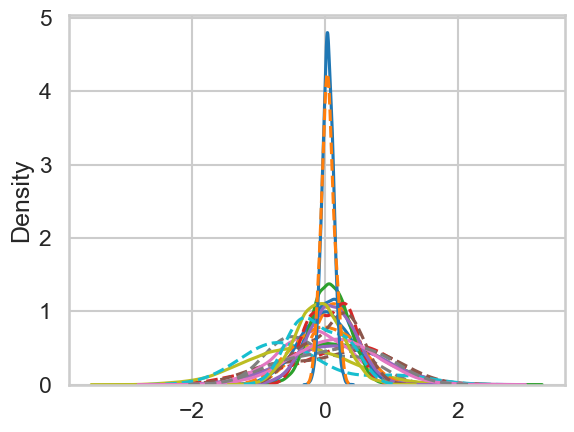

In [35]:
import scipy.stats as stats
for i in range(len(model_harmonize['gamma_hat'])):
    site= stats.norm.rvs(size=10000, loc=model_harmonize['gamma_bar'][i], scale=np.sqrt(model_harmonize['t2'][i]))
    sns.kdeplot(site, label='Site-1-prior')
    sns.kdeplot(model_harmonize['gamma_hat'][i, :], label='Site-1-observed', linestyle='--')
plt.show()

## Age and sex

In [8]:
directory = r'D:\MulticentersEEG\Features_2_normativeModel\gamma_40\24_BEST_EPOCHS\AIF_Babiloni'

aproach1_age_sex = pd.read_feather(rf'{directory}\IAF_FOOOF_ALL_SENSORS\IAF_FOOOF_age_sex.feather')
renombrar_grupos = {'G2': 'HC', 'GU': 'HC', 'CTR': 'HC', 'DCL': 'MCI'}
aproach1_age_sex['group'] = aproach1_age_sex['group'].replace(renombrar_grupos)
goi = ['HC','MCI']
aproach1_age_sex = aproach1_age_sex[aproach1_age_sex['group'].isin(goi)]

dem_cols= list(aproach1_age_sex.columns[:3])+['age_sex']
aproach2_age_sex = pd.read_feather(rf'{directory}\IAF_FOOOF_ROIO_ROIP\rois_age_sex.feather')
aproach2_age_sex['group'] = aproach2_age_sex['group'].replace(renombrar_grupos)
aproach2_age_sex = aproach2_age_sex[aproach2_age_sex['group'].isin(goi)]

aproach3_age_sex = pd.read_feather(rf"{directory}\IAF_FOOOF_ROI_PO\roi_PO_age_sex.feather")
aproach3_age_sex['group'] = aproach3_age_sex['group'].replace(renombrar_grupos)
aproach3_age_sex = aproach3_age_sex[aproach3_age_sex['group'].isin(goi)]

In [ ]:
for method in ['neuroharmonize','recombat']:
    dem_cols= list(aproach1_age_sex.columns[:3])+['age','sex']
    for roi in  ['P7P8','O1O2','PO']: 
        if roi == 'P7P8' or roi == 'O1O2':
            data_roi = pd.concat([aproach2_age_sex[dem_cols],aproach2_age_sex[[i for i in aproach2_age_sex.columns if i.endswith(roi)]]],axis=1)
        elif roi == 'PO':
            data_roi = pd.concat([aproach3_age_sex[dem_cols],aproach3_age_sex[[i for i in aproach3_age_sex.columns if i.endswith('PO')]]],axis=1) 
        family_features = extract_family_features(data_roi)
        for key, features_values in family_features.items():
            if key == 'pw_rel' or key == 'pw_rel_canonic':
                if key == 'pw_rel':
                    filename = f'Pw_rel_{roi}_age_sex'
                else:
                    filename = f'pw_rel_{roi}_age_sex_canonic'
            elif key == 'pw_ab' or key == 'pw_ab_canonic':
                if key == 'pw_ab':
                    filename = f'pw_abs_{roi}_age_sex'
                else:
                    filename = f'pw_abs_{roi}_age_sex_canonic'
            elif key == 'osc_pw_rel' or key == 'osc_pw_canonic':
                if key == 'osc_pw_rel':
                    filename = f'osc_{roi}_age_sex'
                else:
                    filename = f'osc_{roi}_age_sex_canonic'
            elif key == 'osc_pw_ab' or key == 'osc_pw_ab_canonic':
                if key == 'osc_pw_ab':
                    filename = f'osc_abs_{roi}_age_sex'
                else:
                    filename = f'osc_abs_{roi}_age_sex_canonic'
            if  key == 'pw_rel' or key =='pw_rel_canonic' or key == 'pw_ab' or key == 'pw_ab_canonic':        
                features_values = list(features_values) + [f'IAFp_{roi}']
                # Filtrar las features que NO contienen "delta"
                features_values = [f for f in features_values if 'delta' not in f.lower()] #+ [f'IAFp_{roi}']

            elif key == 'osc_pw_rel' or key == 'osc_pw_rel_canonic' or key == 'osc_pw_ab' or key == 'osc_pw_ab_canonic':
                features_values =  [f for f in features_values if 'delta' not in f.lower()] + [ f'exponent_{roi}', f'offset_{roi}']
            if len(features_values) > 1:
                print(key,features_values)
                exclude_cols = [f'CF_extalpha_{roi}',f'TF_{roi}']
                covariates = ['SITE','age', 'sex'] # Covariables
                model_harmonize, harmonize_data = harmonize_transform(data_roi, selected_cols = features_values, electrode=roi, exclude_cols=exclude_cols, smooth_terms=None, covariates=covariates, method=method)
                unharmonize_age_sex, harmonize_age_sex = apply_pca_umap(data_roi, harmonize_data, features_values, directory, n_pca=3, n_neighbors=40, min_dist=0.4, filename= filename, method= method,aproach = 'age_sex_ByROI', family_features= key)
    

pw_rel ['pw_theta_P7P8', 'pw_BGF1_P7P8', 'pw_BGF2_P7P8', 'pw_BGF3_P7P8', 'pw_beta_P7P8', 'IAFp_P7P8']
pw_rel_canonic ['pw_canonic_theta_P7P8', 'pw_canonic_alpha1_P7P8', 'pw_canonic_alpha2_P7P8', 'pw_canonic_beta1_P7P8', 'pw_canonic_beta2_P7P8', 'pw_canonic_beta3_P7P8', 'pw_canonic_gamma_P7P8', 'IAFp_P7P8']
pw_ab ['pw_ab_theta_P7P8', 'pw_ab_BGF1_P7P8', 'pw_ab_BGF2_P7P8', 'pw_ab_BGF3_P7P8', 'pw_ab_beta_P7P8', 'IAFp_P7P8']
pw_ab_canonic ['pw_ab_canonic_theta_P7P8', 'pw_ab_canonic_alpha1_P7P8', 'pw_ab_canonic_alpha2_P7P8', 'pw_ab_canonic_beta1_P7P8', 'pw_ab_canonic_beta2_P7P8', 'pw_ab_canonic_beta3_P7P8', 'pw_ab_canonic_gamma_P7P8', 'IAFp_P7P8']
osc_pw_rel ['osc_pw_theta_P7P8', 'osc_pw_BGF1_P7P8', 'osc_pw_BGF2_P7P8', 'osc_pw_BGF3_P7P8', 'osc_pw_beta_P7P8', 'exponent_P7P8', 'offset_P7P8']
osc_pw_rel_canonic ['osc_pw_canonic_theta_P7P8', 'osc_pw_canonic_alpha1_P7P8', 'osc_pw_canonic_alpha2_P7P8', 'osc_pw_canonic_beta1_P7P8', 'osc_pw_canonic_beta2_P7P8', 'osc_pw_canonic_beta3_P7P8', 'osc_pw_c